In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_kalman_tb import combinedPointCloudKalmanTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman


In [2]:
#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path="/data/radnav/rad_nav_filter_experiments/wilk_filter_test_1/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilkinson.yaml"
)

found 1095 radar samples
found 1095 lidar samples
did not find camera samples
found 1095 imu (orientation only) samples
found 1095imu (full data) samples
found 1095 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.3,#originally 0.5
    icp_best_points_percentile=70,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #originally 0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 20750 points
loaded map with 20750 points
gt icp estimated heading:-3.7907536988462005 deg, pose:[-0.06649875 -0.13701971]
radar icp estimated heading:-8.395111272274967 deg, pose:[-0.00860564 -0.21586183]


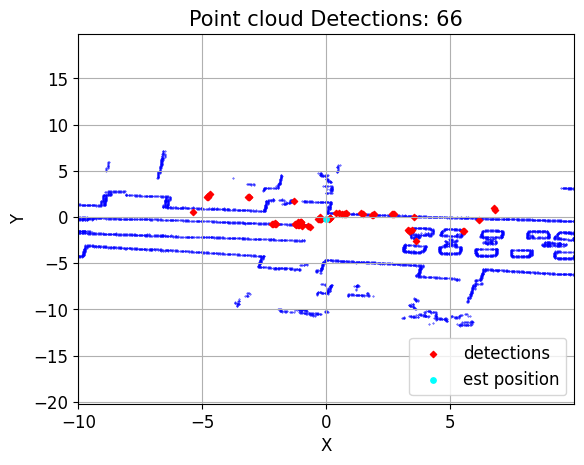

In [4]:
#initialize the test bench
test_bench = combinedPointCloudKalmanTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(-3.78)
start_pose = np.array([-0.07,-0.13])

new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

In [5]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=start_time_s
)

dataset start time: 1716410866.672556s


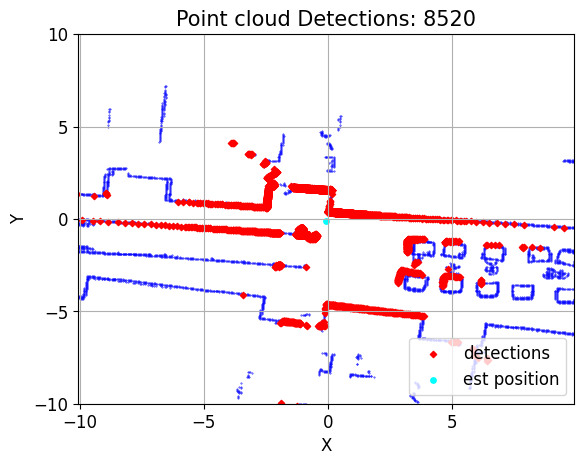

In [6]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter.plot_lidar_points_on_map(
    idx=0,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

In [7]:
end_idx = 530
test_bench.run(max_frame=end_idx)

100%|██████████| 530/530 [00:00<00:00, 642.89it/s]


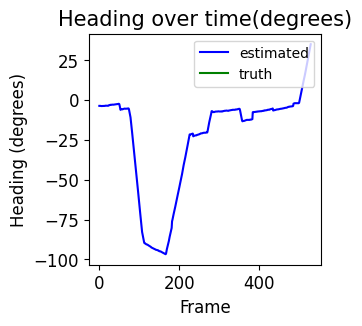

In [8]:
test_bench.plotter.plot_heading_history_deg(
    history_heading_deg=test_bench.history_heading_deg,
    history_heading_deg_gt=test_bench.history_heading_deg_gt,
    idx = 0,
    ax=None,
    show=True
)

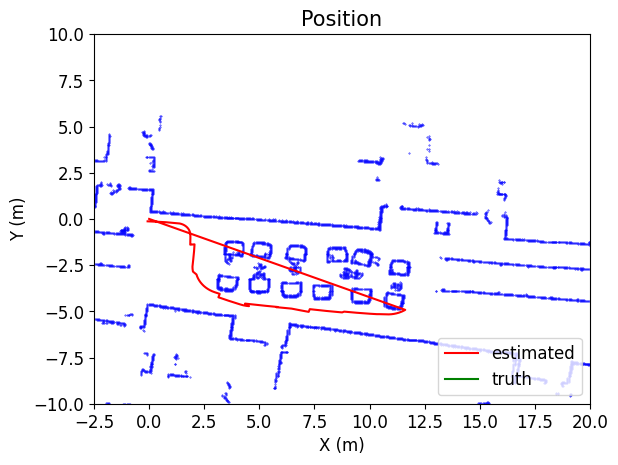

In [9]:
fig,ax = plt.subplots()
test_bench.plotter.plot_position_history_m(
    history_position_m=test_bench.history_position_m,
    history_position_m_gt=test_bench.history_position_m_gt,
    idx=0,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
ax.set_xlim(-2.5,20)
plt.show()

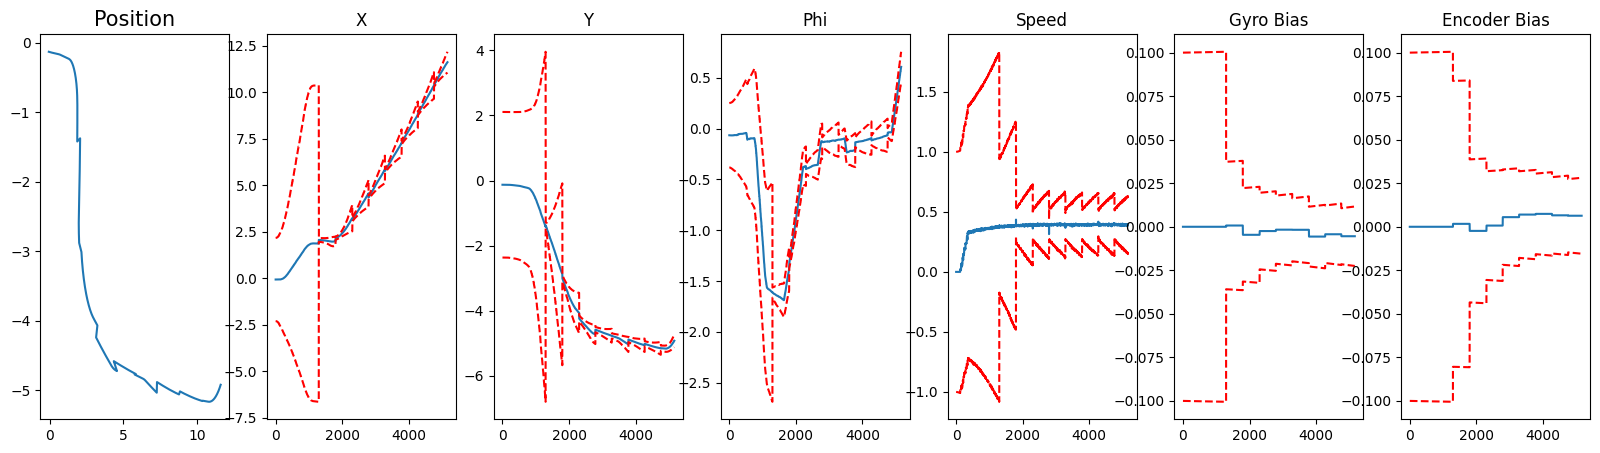

In [10]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=0
)

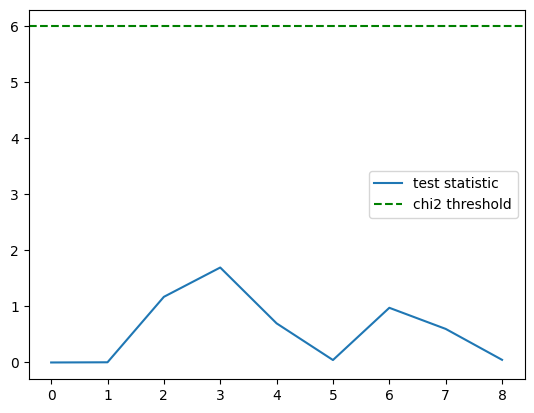

[0, 0.0034211320735810517, 1.1704405568297065, 1.6933650810555918, 0.6976789017758767, 0.04361134264175145, 0.9750471445489426, 0.5985724451420289, 0.04716567909073408]


In [11]:
kalman_plotter.plot_chi_2_resp(
    g_thresh=test_bench.filter.g_thresh[2],
    g_hist=np.array(test_bench.history_filter_g),
    idx=0
)
print(test_bench.history_filter_g)

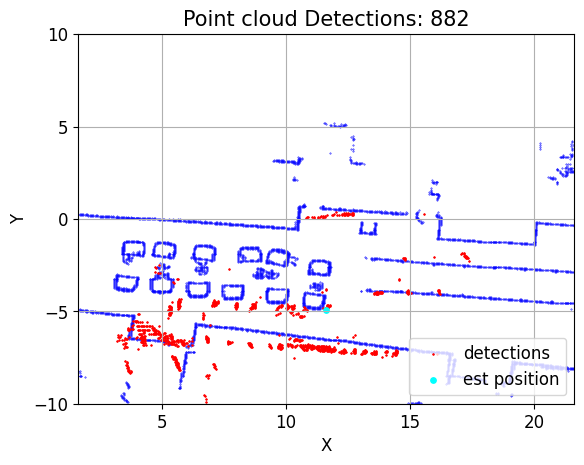

In [12]:
combined_point_cloud = test_bench.point_cloud_stacker.get_points()


# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter.marker_size=0.5
test_bench.plotter.plot_detections_on_map(
    current_points=combined_point_cloud,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

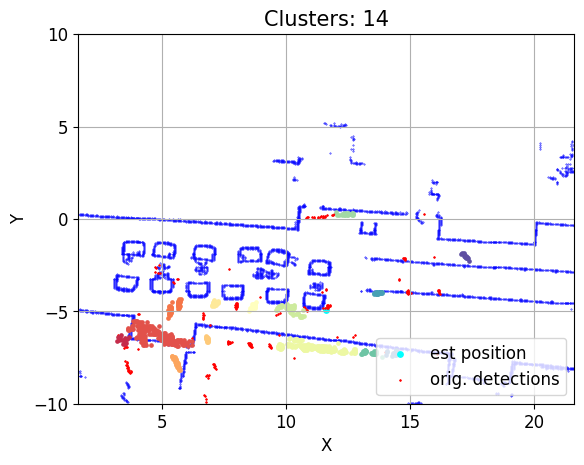

In [13]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=0.3,
    clustering_min_samples=15
)

labels = multipath._cluster_points(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter.marker_size=0.5
test_bench.plotter.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart,
    labels=labels,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

ax.set_ylim(-10,10)
plt.show()

In [14]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
    valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

100%|██████████| 1000/1000 [00:03<00:00, 261.51it/s]


<function matplotlib.pyplot.show(close=None, block=None)>

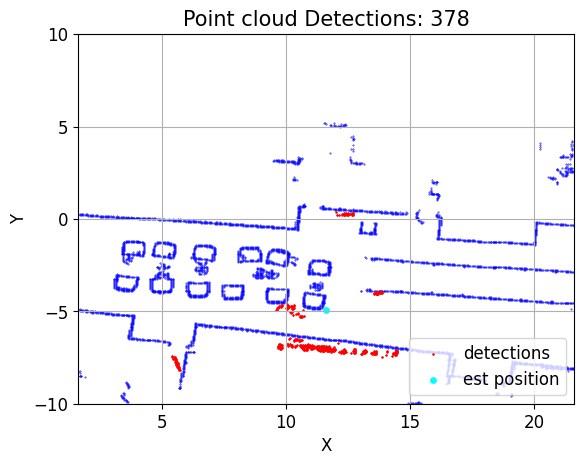

In [15]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter.marker_size=0.5
test_bench.plotter.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

Filter estimate: heading: 0.6080236754189128 rad, pose: [11.61662133 -4.92060758] m
New estimate: heading: 0.5754517446590227 rad, pose: [11.9528071  -4.50352043] m
GT: heading: -0.06616113317701977 rad, pose: [-0.06649875 -0.13701971] m


<function matplotlib.pyplot.show(close=None, block=None)>

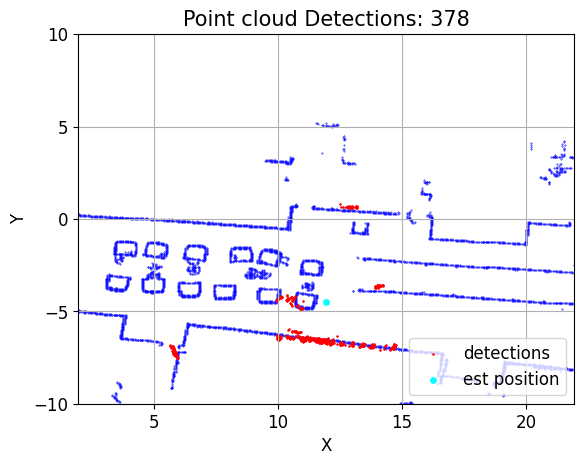

In [16]:
#perform an ICP update

est_heading_rad,est_pose_m = test_bench.localizer.update_odometry(
    points=valid_stacked_pc_cart,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
)

print("Filter estimate: heading: {} rad, pose: {} m".format(
    test_bench.filter.x[2],
    np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
))
print("New estimate: heading: {} rad, pose: {} m".format(
    est_heading_rad,est_pose_m
))
print("GT: heading: {} rad, pose: {} m".format(
    test_bench.gt_localizer.current_heading_rad,
    test_bench.gt_localizer.current_pose_m
))

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter.marker_size=0.5
test_bench.plotter.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=est_heading_rad,
    pose_m=est_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show